### Simulating 2D lines of electrodes 

- Simulating electrodes where the exponent is -1 for each
- Explore what happens to the output exponent when you average:
    - The time series
    - The PSDs
    - The exponent outputs from the model fit
- Simulate this for both aperiodic and full electrode signals

#### Imports

In [1]:
# Imports required for functionality 
import numpy as np
import matplotlib.pyplot as plt

from neurodsp.plts import plot_time_series
from neurodsp.spectral import compute_spectrum_welch

from specparam import SpectralModel
from specparam.plts import plot_spectra

from dissertation_simulations.params import welch_params, spectral_model_params, freq_range, cz_sim_params_ap
from dissertation_simulations.generate_electrodes import generate_2D_electrodes_ap


#### Testing the function - 4 electrodes, 2x2 cluster, aperiodic noise only, exponent = -1 for each

Aim:
- Generate 4 electrode signals
- Each electrode signal should have an exponent of -1

#### Averaging the Time Series together

- Compute and plot the average time series for the 4 signals
- Compute and plot the PSD
- Fit the Spectral Model and see what the exponent is

In [2]:
# Generate 2x2 cluster
exponents = [-1, -1, -1, -1]
grid_signals, times = generate_2D_electrodes_ap(2, 2, exponents)

##### Plot time series

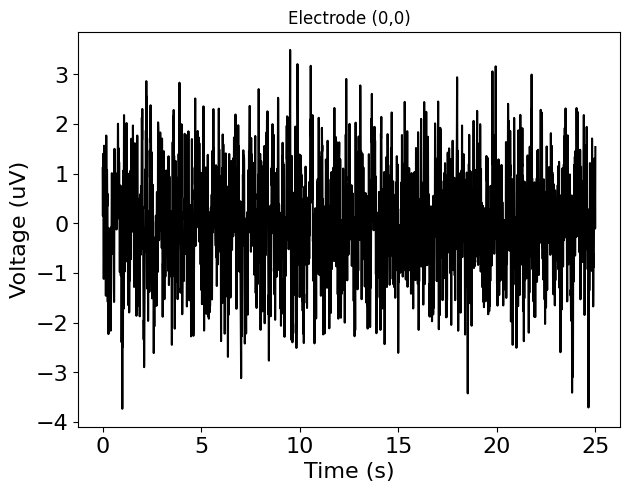

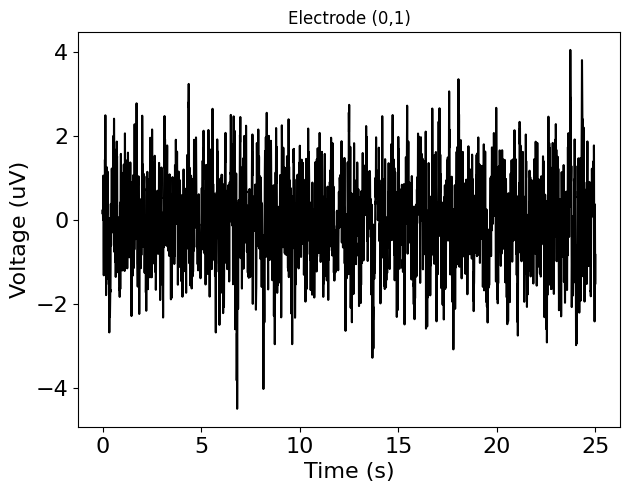

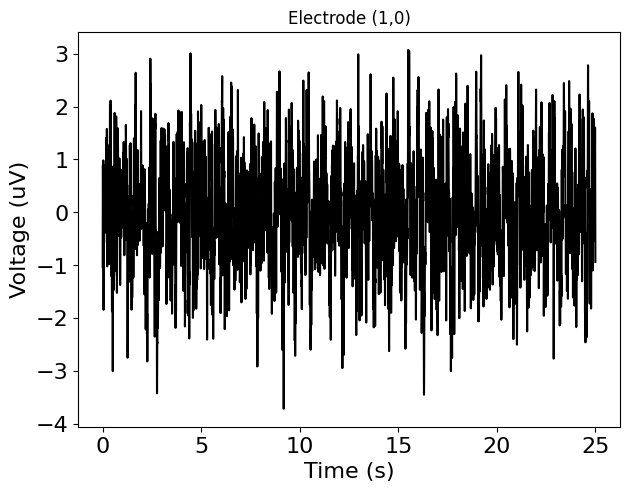

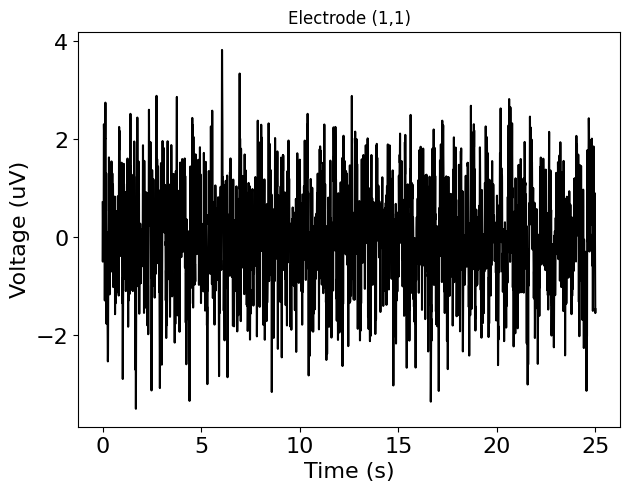

In [3]:
n_rows, n_cols, _ = grid_signals.shape

for i in range(n_rows):
    for j in range(n_cols):
        fig, ax = plt.subplots()

        signal = grid_signals[i, j]

        plot_time_series(times, signal, ax=ax)
        ax.set_title(f"Electrode ({i},{j})")

        plt.show()

##### Average time series

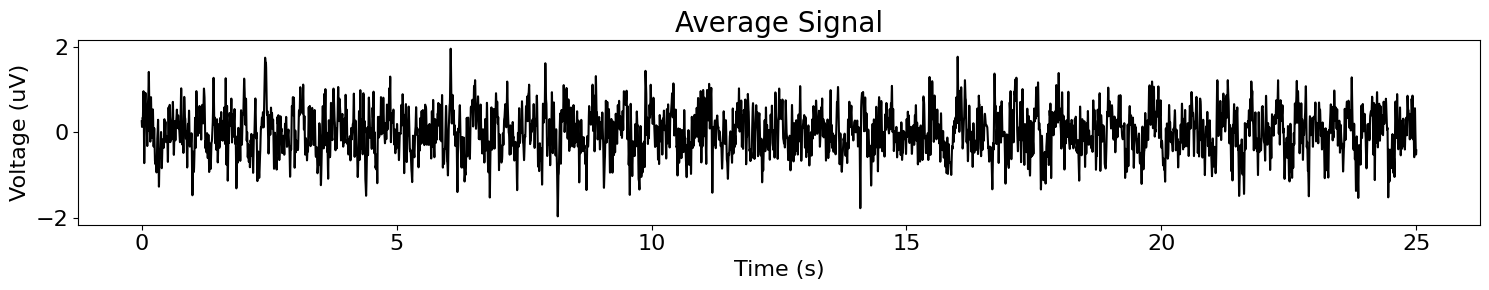

In [4]:
# Average across rows and columns
avg_signal = np.mean(grid_signals, axis=(0, 1))

# Plot
plot_time_series(times, avg_signal, title="Average Signal")

##### Plot PSD

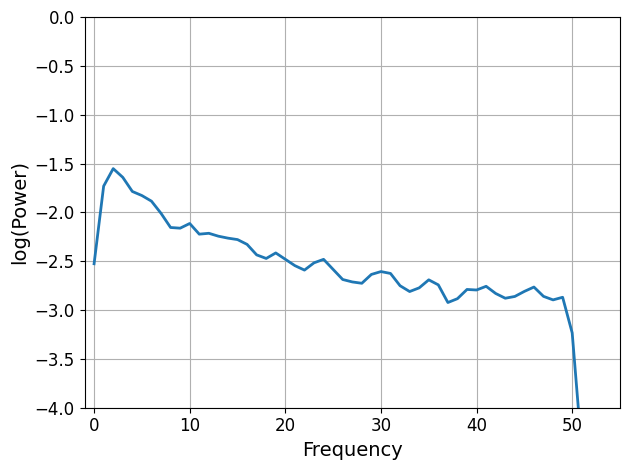

In [5]:
# Compute and plot the PSD, in the frequency domain
params = cz_sim_params_ap.copy()
welch_dict = welch_params(params)

fig, ax = plt.subplots()

freqs, powers = compute_spectrum_welch(avg_signal, fs=params["s_rate"], **welch_dict)
plot_spectra(freqs, powers, log_powers=True, ax=ax)

ax.set_xlim(-1, 55)
ax.set_ylim(-4, 0)

plt.show()

##### Plot Spectral Model

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, exponent)                                        
                                         -1.1762, 1.0595                                          
                                                                                                  
          

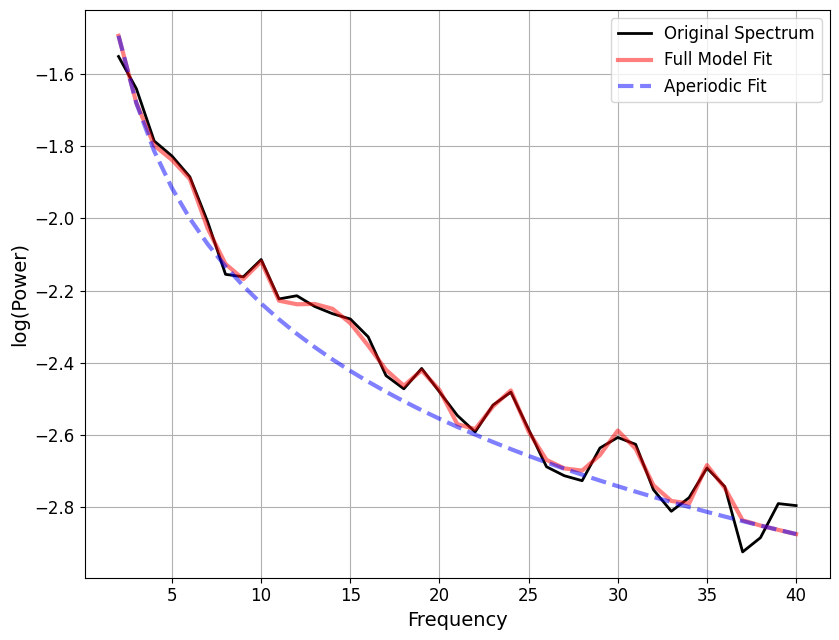

In [6]:
# Plot Spectral Model and look at the exponent output 
fm = SpectralModel(**spectral_model_params)
freq_range = freq_range

fm.report(freqs, powers, freq_range)

#### Averaging the PSD together

- Compute and plot the time series for the 4 signals
- Compute and plot the average PSD
- Fit the Spectral Model and see what the exponent is

In [7]:
# Generate 2x2 cluster
exponents = [-1, -1, -1, -1]
grid_signals, times = generate_2D_electrodes_ap(2, 2, exponents)

##### Plot time series

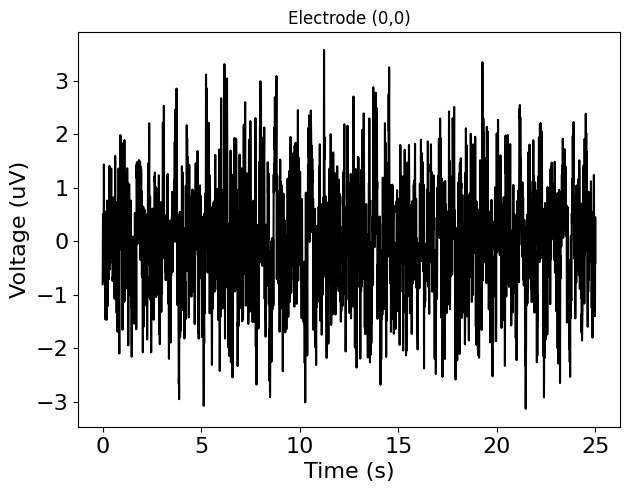

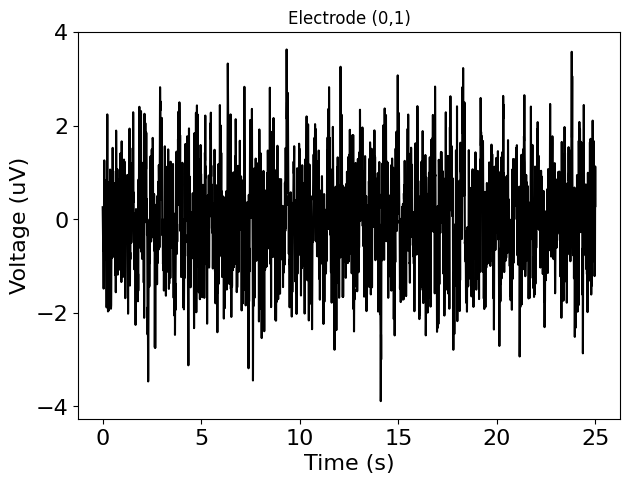

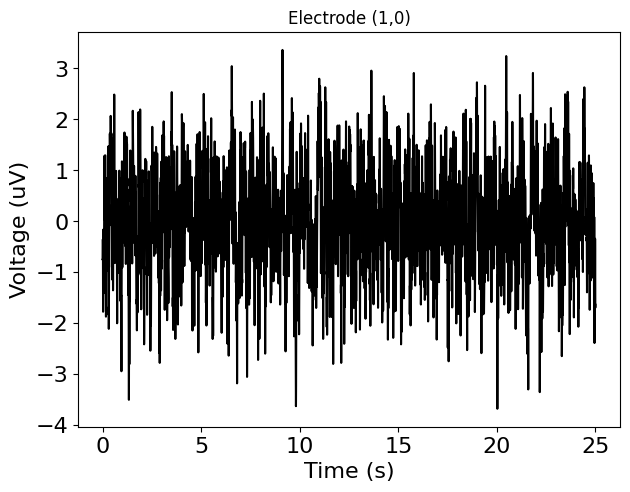

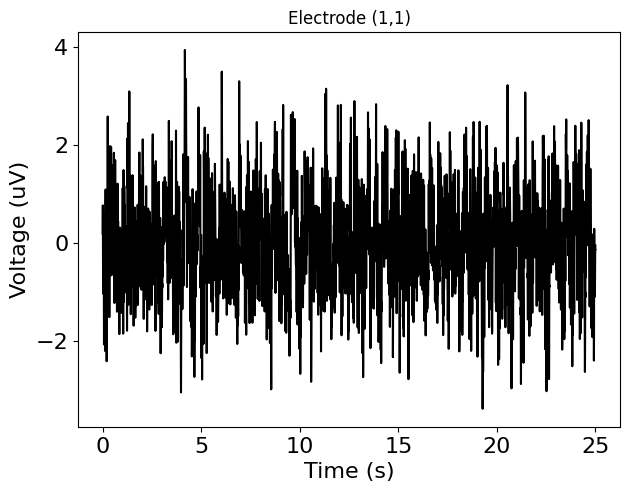

In [8]:
n_rows, n_cols, _ = grid_signals.shape

for i in range(n_rows):
    for j in range(n_cols):
        fig, ax = plt.subplots()

        signal = grid_signals[i, j]

        plot_time_series(times, signal, ax=ax)
        ax.set_title(f"Electrode ({i},{j})")

        plt.show()

#### Plot PSDs

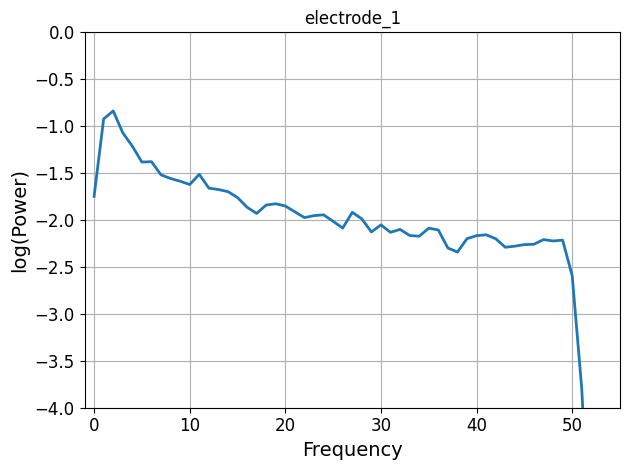

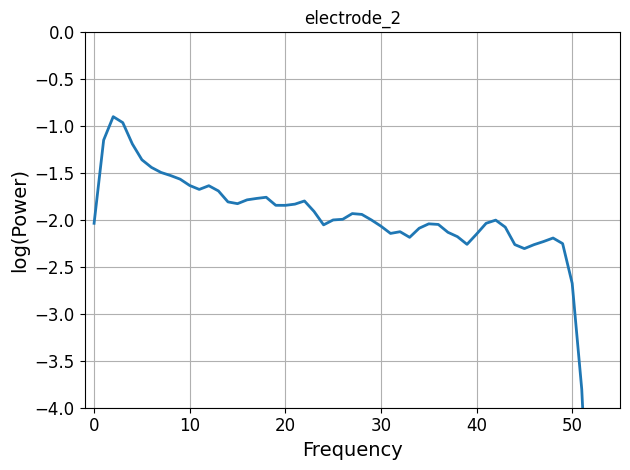

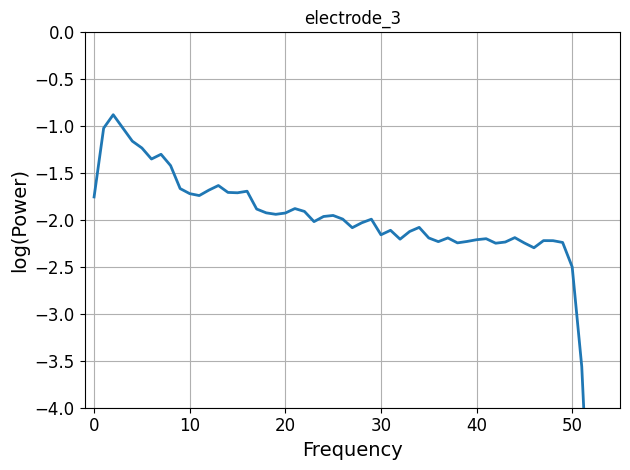

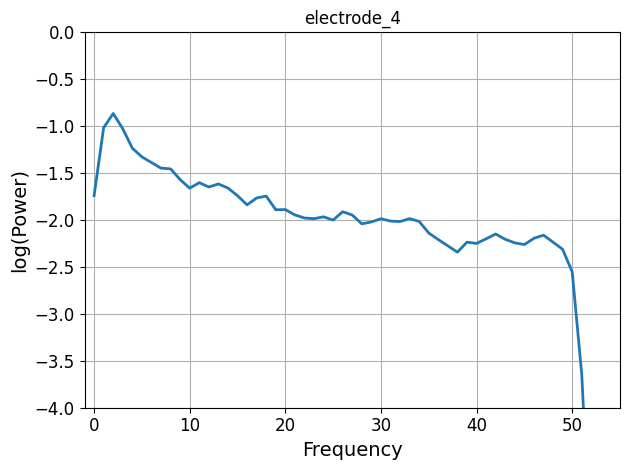

In [9]:
# Compute and plot the individual PSDs, in the frequency domain
psds = {}

params = cz_sim_params_ap.copy()
welch_dict = welch_params(params)

n_rows, n_cols, _ = grid_signals.shape

for i in range(n_rows):
    for j in range(n_cols):
        
        fig, ax = plt.subplots()

        signal = grid_signals[i, j]

        freqs, powers = compute_spectrum_welch(signal, fs=params["s_rate"], **welch_dict)

        name = f"electrode_{i*n_cols + j + 1}"

        psds[name] = (freqs, powers)

        plot_spectra(freqs, powers, log_powers=True, ax=ax)

        ax.set_title(name)
        ax.set_xlim(-1, 55)
        ax.set_ylim(-4, 0)

        plt.show()

##### Average PSD

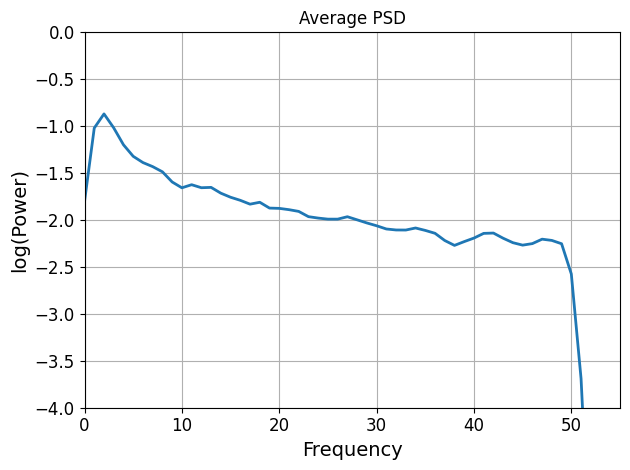

In [10]:
power_array = np.array([powers for freqs, powers in psds.values()])
avg_powers = np.mean(power_array, axis=0)

freqs = list(psds.values())[0][0]

fig, ax = plt.subplots()

plot_spectra(freqs, avg_powers, log_powers=True, ax=ax)

ax.set_title("Average PSD")
ax.set_xlim(0, 55)
ax.set_ylim(-4, 0)

plt.show()

##### Plot Spectral Model

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, exponent)                                        
                                         -0.5472, 1.0673                                          
                                                                                                  
          

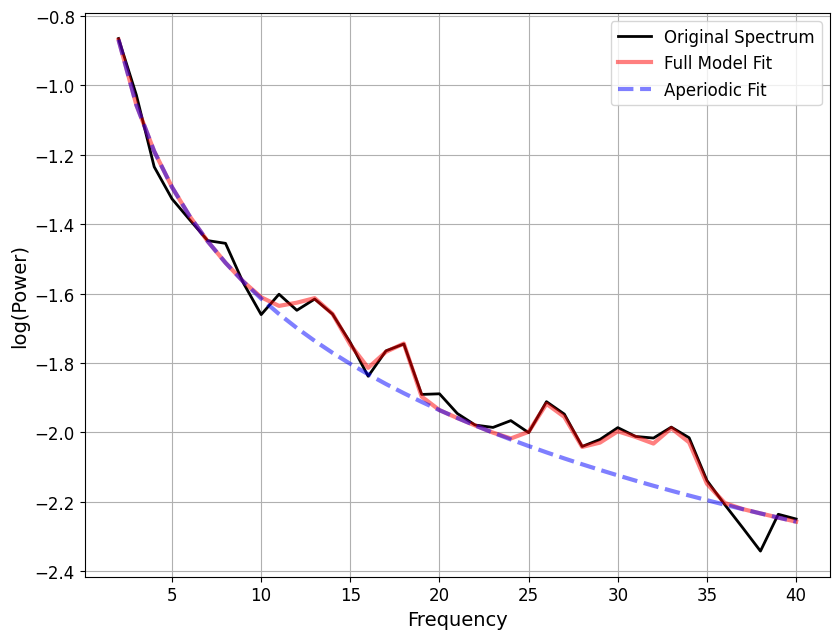

In [11]:
# Plot Spectral Model and look at the exponent output 
fm = SpectralModel(**spectral_model_params)
freq_range = freq_range

fm.report(freqs, powers, freq_range)

#### Averaging the Spectral Models together

- Compute and plot the time series for the 4 signals
- Compute and plot the PSDs for the 4 signals
- Fit the Spectral Models for each signal and calculate the average exponent

In [12]:
# Generate 2x2 cluster
exponents = [-1, -1, -1, -1]
grid_signals, times = generate_2D_electrodes_ap(2, 2, exponents)

##### Plot the time series

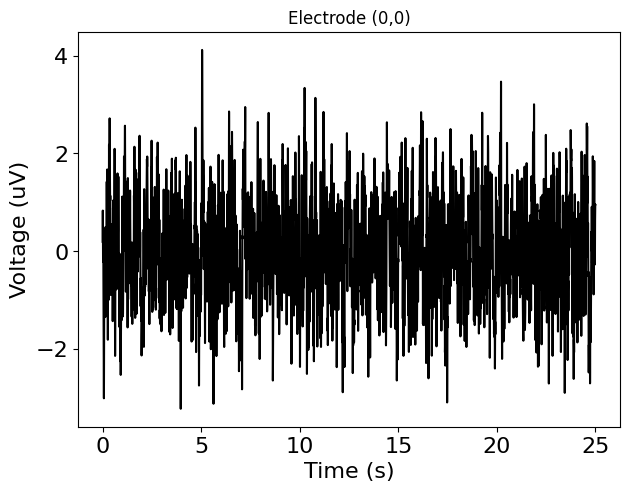

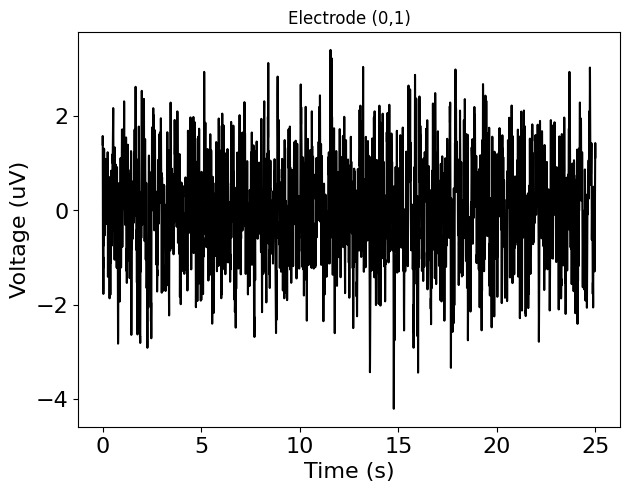

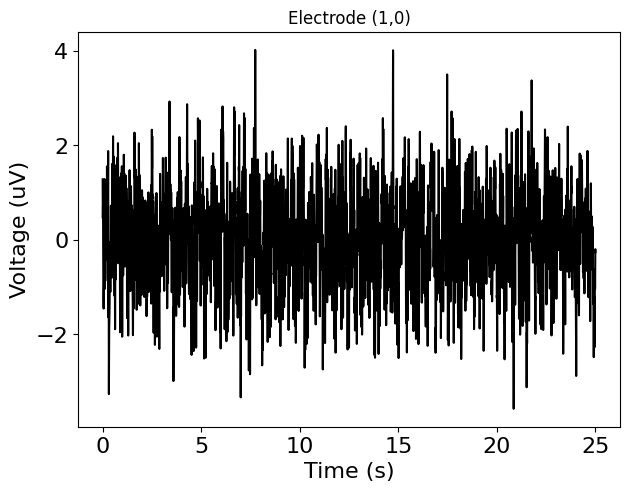

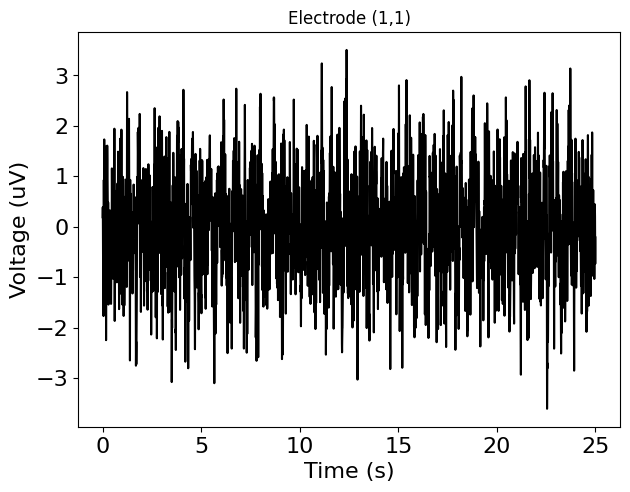

In [13]:
n_rows, n_cols, _ = grid_signals.shape

for i in range(n_rows):
    for j in range(n_cols):
        fig, ax = plt.subplots()

        signal = grid_signals[i, j]

        plot_time_series(times, signal, ax=ax)
        ax.set_title(f"Electrode ({i},{j})")

        plt.show()

##### Plot the individual PSDs

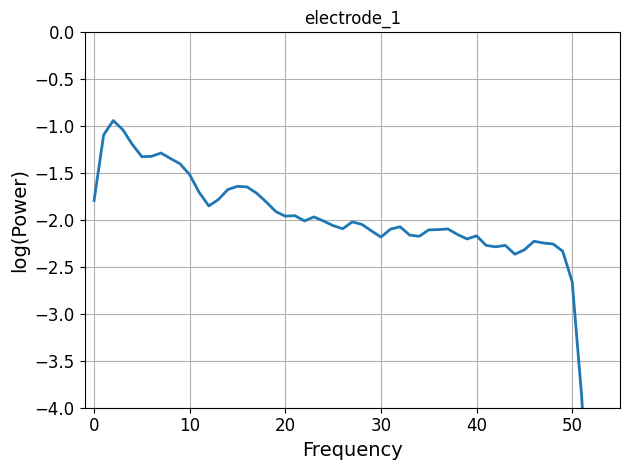

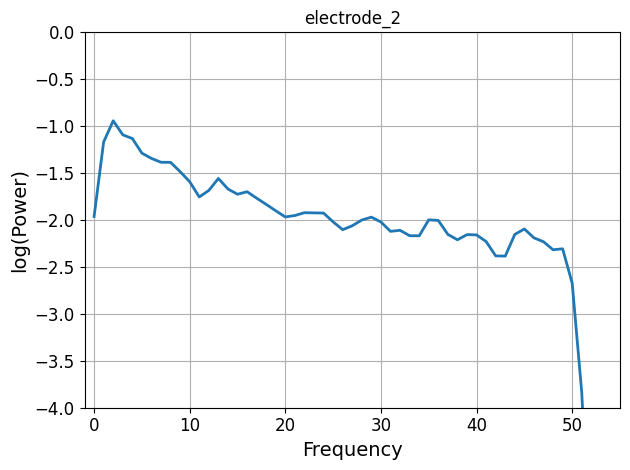

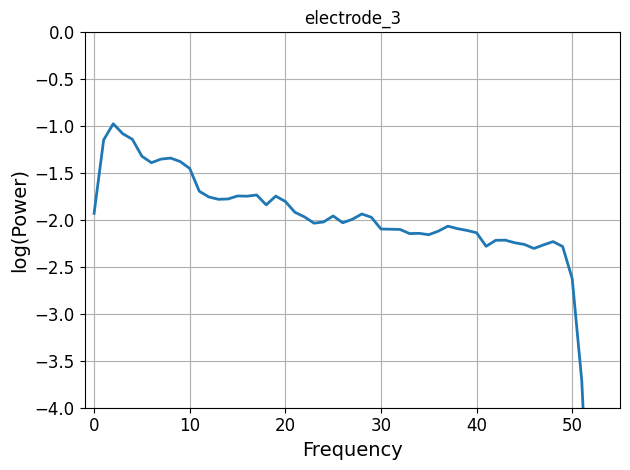

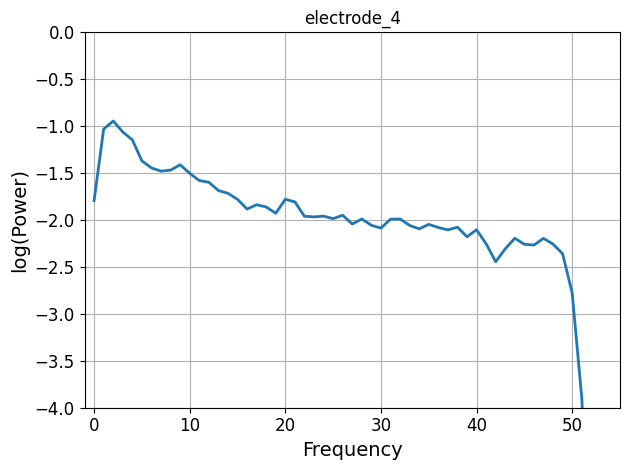

In [14]:
# Compute and plot the individual PSDs, in the frequency domain
psds = {}

params = cz_sim_params_ap.copy()
welch_dict = welch_params(params)

n_rows, n_cols, _ = grid_signals.shape

for i in range(n_rows):
    for j in range(n_cols):
        
        fig, ax = plt.subplots()

        signal = grid_signals[i, j]

        freqs, powers = compute_spectrum_welch(signal, fs=params["s_rate"], **welch_dict)

        name = f"electrode_{i*n_cols + j + 1}"

        psds[name] = (freqs, powers)

        plot_spectra(freqs, powers, log_powers=True, ax=ax)

        ax.set_title(name)
        ax.set_xlim(-1, 55)
        ax.set_ylim(-4, 0)

        plt.show()

##### Plot the indiviudal Spectral Models

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 1.00 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, exponent)                                        
                                         -0.6123, 1.0254                                          
                                                                                                  
          

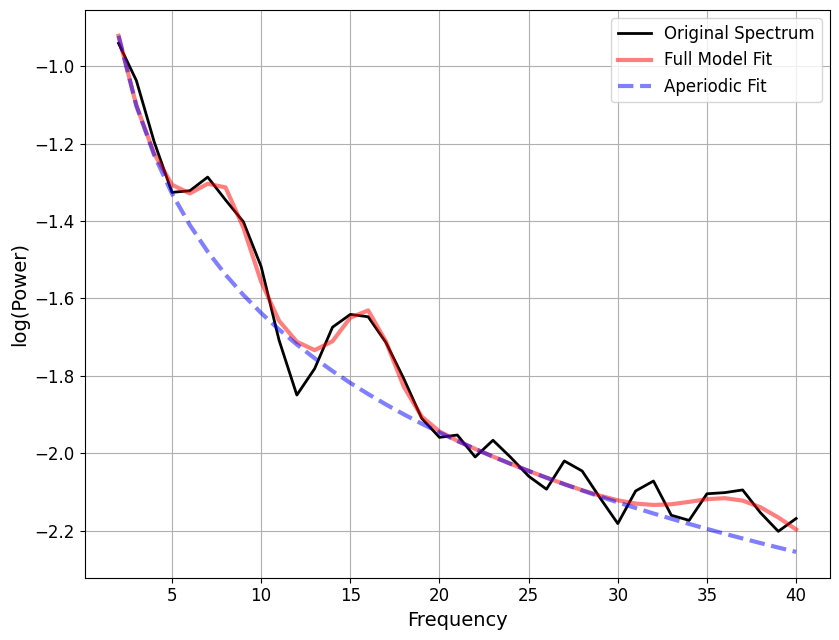

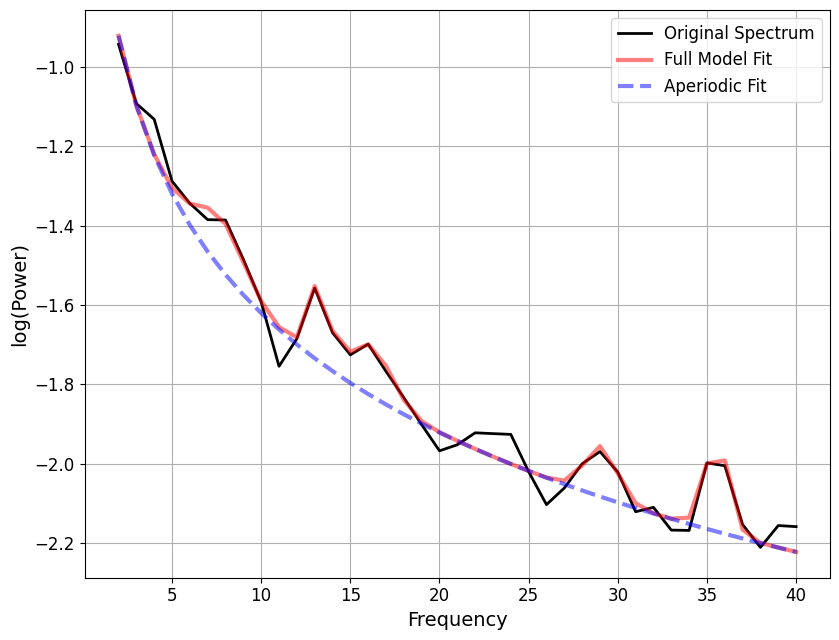

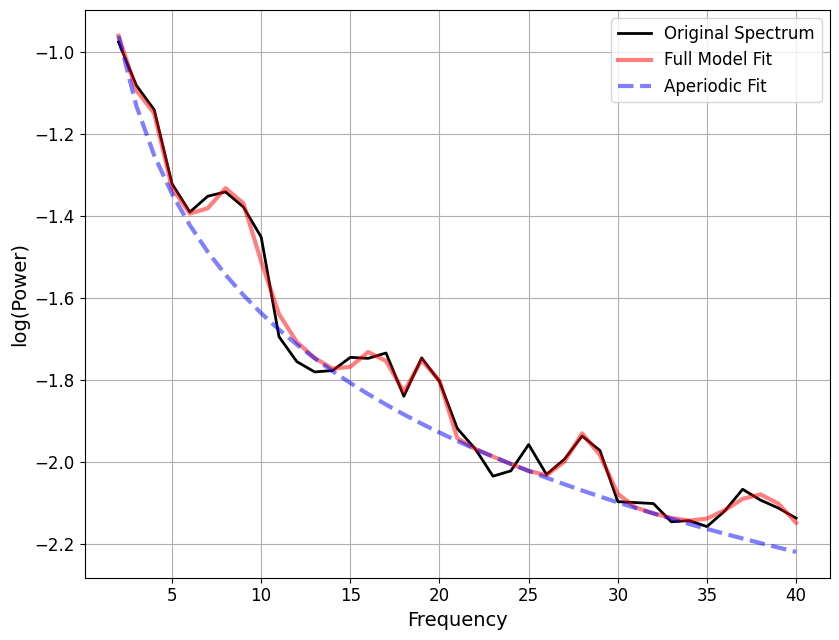

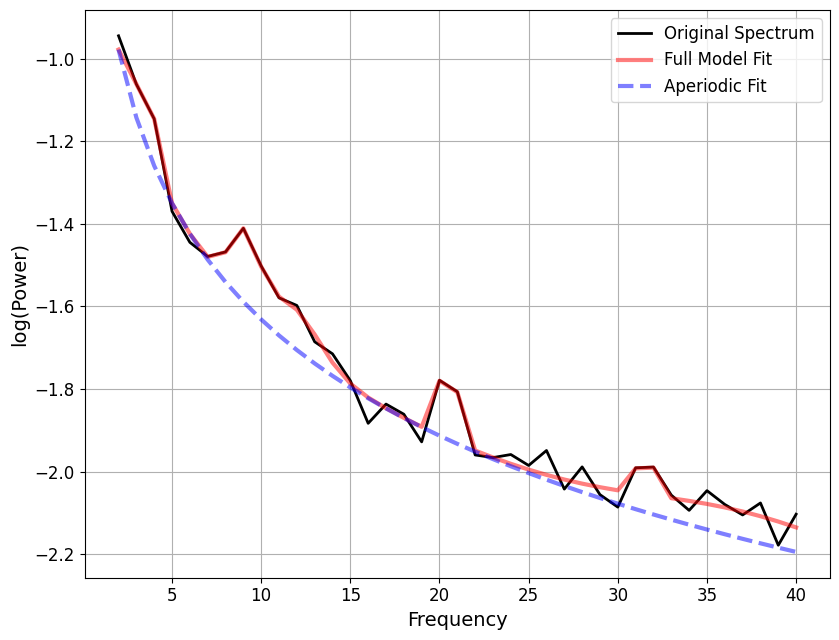

In [15]:
spectral_models = {}

for name, (freqs, powers) in psds.items():

    # Fit model
    fm = SpectralModel(**spectral_model_params)
    freq_range = freq_range
    fm.report(freqs, powers, freq_range)

    spectral_models[name] = fm

##### Average the exponent output

In [16]:
exponents = []

for name, fm in spectral_models.items():
    exponent = fm.get_params('aperiodic', 'exponent')
    exponents.append(exponent)
    print(f"{name}: {exponent:.3f}")

avg_exponent = np.mean(exponents)

print(f"Average exponent: {avg_exponent:.3f}")

electrode_1: 1.025
electrode_2: 1.000
electrode_3: 0.967
electrode_4: 0.935
Average exponent: 0.982
